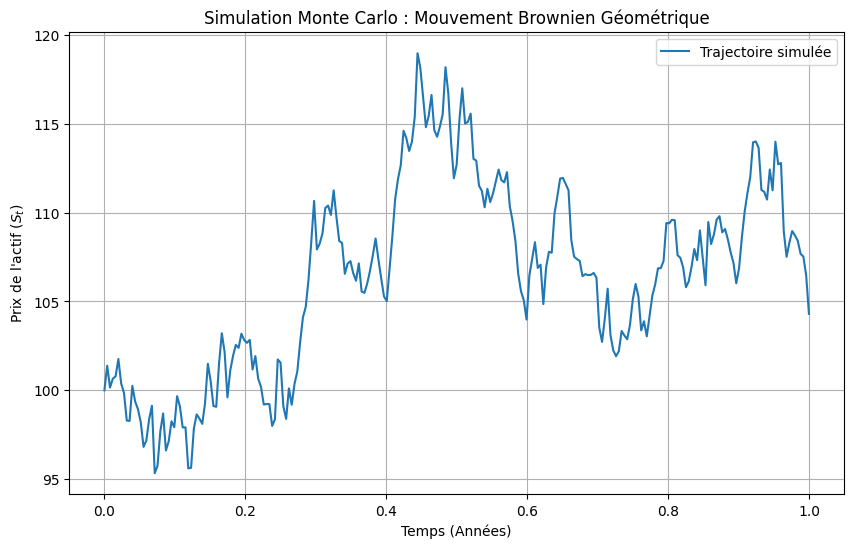

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Paramètres du Marché ---
S0 = 100       # Prix initial de l'action
T = 1.0        # Durée (1 an)
r = 0.05       # Taux d'intérêt (5%)
sigma = 0.2    # Volatilité (20% de remous)
n_steps = 252  # Jours de trading dans un an

# --- 2. Préparation du Temps ---
dt = T / n_steps                # Durée d'un pas de temps (1 jour)
t = np.linspace(0, T, n_steps + 1) # Axe temporel (0, 1/252, 2/252... 1)

# --- 3. Le Moteur (La boucle) ---
# On crée un tableau vide pour stocker les prix
S = np.zeros(n_steps + 1)
S[0] = S0

# On avance jour après jour
for i in range(1, n_steps + 1):
    # Z : Le tirage aléatoire (Loi Normale centrée réduite)
    Z = np.random.normal(0, 1) 
    
    # La formule du cours (GBM)
    drift = (r - 0.5 * sigma**2) * dt
    shock = sigma * np.sqrt(dt) * Z
    
    # Prix jour suivant = Prix jour actuel * variation
    S[i] = S[i-1] * np.exp(drift + shock)

# --- 4. Visualisation ---
plt.figure(figsize=(10, 6))
plt.plot(t, S, label='Trajectoire simulée')
plt.title(f"Simulation Monte Carlo : Mouvement Brownien Géométrique")
plt.xlabel("Temps (Années)")
plt.ylabel("Prix de l'actif ($S_t$)")
plt.legend()
plt.grid(True)
plt.show()